## Imports and Constants ##

In [1]:
pip install colour-science

Note: you may need to restart the kernel to use updated packages.


In [6]:
# for CIE analysis
import colour
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import pandas as pd
import scipy.constants as sc
from scipy.interpolate import interp1d
from scipy import optimize
from scipy.optimize import fsolve

def spectrum_to_html(wavelengths, values):
    # Spectrum
    sd = colour.SpectralDistribution(
        dict(zip(wavelengths, values))
    )

    # Spectrum -> CIE XYZ
    XYZ = colour.sd_to_XYZ(sd)

    # Normalize so we're showing hue/color rather than absolute brightness
    XYZ = XYZ / np.max(XYZ)

    # CIE XYZ -> sRGB
    RGB = colour.XYZ_to_sRGB(XYZ)

    # Bring out-of-gamut values into displayable range
    RGB = np.clip(RGB, 0, 1)

    return RGB

np.set_printoptions(precision=2)

In [8]:
conv_flux = 1e10 # convert W/cm^2/micron to W/m^2/meters
m2mm = 1e3 # convert from m to millimeters
m2um = 1e6 # convert from m to micrometers
m2nm = 1e9 # convert from m to nanometers
mol2umol = 1e6 # convert from micromoles to moles
mW2W = 1e-3 # convert from milliwatts to watts
y2s = 86400*365.25 # convert from years to seconds

# flux scaling factors for the three test cases
# Mars is mid-latitude, other two are equatorial
flux_scale_factor_Mars     = 1.0/1.524**2/4
flux_scale_factor_Ceres    = 1.0/2.77**2/2
flux_scale_factor_Callisto = 1.0/5.2**2/2

# solar zenith angle cosine (SZA = 60 degrees)
mu_av = 0.5

# parameters for convection calculation
g_Mars = 3.72 # Mars gravity [m s^-2]
g_Ceres = 0.284 # Ceres gravity [m s^-2]
g_Callisto = 1.236 # Callisto gravity [m s^-2]
grav_array = np.array([g_Mars,g_Ceres,g_Callisto])

alpha = 2e-5 # air thermal diffusivity [m^2 s^-1]
nu = 1.5e-5 # air kinematic viscosity [m^2 s^-1]
L = 3.0 # habitat height (irrelevant; cancels) [m]
beta = 3.4e-3 # air thermal expansion coefficient [K^-1]
k_air = 0.025 # air thermal conductivity [W m^-1 K^-1]

## Data Load in and Pre-Processing ##

In [10]:
ice_ascii = pd.read_csv('your file location here/IOP_2008_ASCIItable.dat.txt', sep=r'\s+', header=None) # Enter your file location, ice data from warren et al. 2019
# Replace with the location of your file on local machine
row_name = ['Wavelength', 'real', 'imaginary']
ice_ascii.columns = row_name

sun_data =  pd.read_csv('your file location here/sunum.txt', sep='\t') # Enter your file location, solar spectrum data
sun_array = sun_data.to_numpy()

## Plot Index of Refraction vs. Wavelength (Warren 2019) (Figure 1a) ##

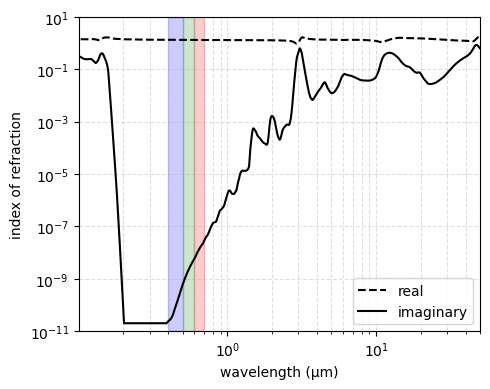

In [12]:
# Plot real part of index of refraction data from Warren 2019
# Plot imaginary part of index of refraction data from Warren 2019, and highlight the visible region

fig, ax = plt.subplots(figsize=(5,4))

# plt.figure(figsize=(5, 4), dpi=120)

ax.plot(ice_ascii['Wavelength'], ice_ascii['real'],color='k',linestyle='dashed',label='real') # plot wavelength vs. real index of refraction
ax.plot(ice_ascii['Wavelength'], ice_ascii['imaginary'],color='k',label='imaginary') # plot wavelength vs. imaginary index of refraction
ax.set_xscale('log') # log scale
ax.set_yscale('log') # log scale
ax.set_xticks([1, 10, 1e2])
ax.set_xlabel('wavelength (µm)')
ax.set_ylabel('index of refraction')

ax.axvspan(0.4, 0.5, color='blue', alpha=0.2) # blue visible wavelength region
ax.axvspan(0.5, 0.6, color='green', alpha=0.2) # green visible wavelength region
ax.axvspan(0.6, 0.7, color='red', alpha=0.2) # red visible wavelength region

ax.set_xlim([0.1, 50])
ax.set_ylim([1e-11, 1e1]) 
ax.grid(True, which="both", ls="--", alpha=0.4)


plt.legend()
plt.tight_layout()
plt.show()

## Interpolate Values onto Regular Grid ##

total solar flux =  1362.15079737 W m^-2


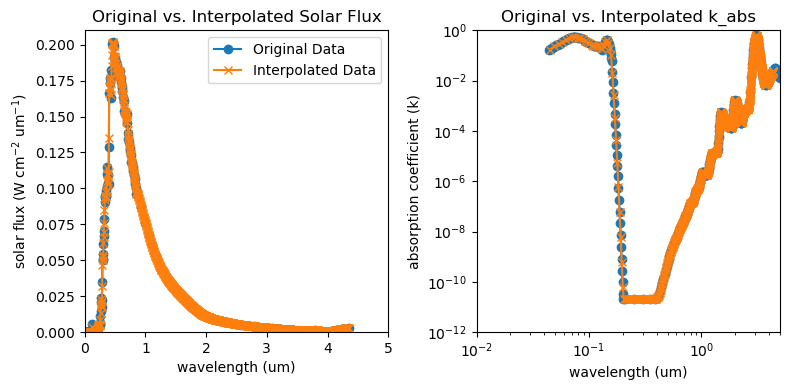

In [14]:
lambda_a = np.linspace(0.045,4.35,1000)/m2um # wavelength array (m)

interp_sol = interp1d(sun_array[:, 0]/m2um, sun_array[:, 1]*conv_flux, kind='linear', fill_value="extrapolate") # interpolate solar spectrum
interp_RIr = interp1d(ice_ascii['Wavelength']/m2um, ice_ascii['imaginary'], kind='linear', fill_value="extrapolate") # interpolate imaginary refractive index
interp_RIi = interp1d(ice_ascii['Wavelength']/m2um, ice_ascii['real'], kind='linear', fill_value="extrapolate") # interpolate real refractive index

Fsol   = interp_sol(lambda_a) # apply solar flux on wavelength grid
RIimag = interp_RIr(lambda_a) # apply imaginary refractive index on wavelength grid
RIreal = interp_RIi(lambda_a) # apply real refractive index on wavelength grid

# checks
flux_sol_tot = np.trapezoid(Fsol,lambda_a) # verifies that the total is around 1362 W/m^2
print('total solar flux = ',flux_sol_tot,'W m^-2') #

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.plot(sun_array[:, 0], sun_array[:, 1], 'o-', label='Original Data') # plots original solar spectrum
plt.plot(lambda_a*m2um,Fsol/conv_flux,'x-', label='Interpolated Data') # plots interpolated solar spectrum
plt.xlabel('wavelength (um)')
plt.ylabel(r'solar flux (W cm$^{-2}$ um$^{-1}$)')
plt.title('Original vs. Interpolated Solar Flux')
plt.axis([0,5,0,0.21])
plt.legend()

plt.subplot(122)
plt.loglog(ice_ascii['Wavelength'], ice_ascii['imaginary'], 'o-') # plots original imaginary refractive index
plt.plot(lambda_a*m2um,RIimag,'x-') # plots interpolated imaginary refractive index
plt.xlabel('wavelength (um)')
plt.ylabel(r'absorption coefficient (k)')
plt.title('Original vs. Interpolated k_abs')
plt.axis([0.01,5,1e-12,1e0])

plt.tight_layout()
plt.show()

## Calculate Absorption Coefficient k$_{abs}(\lambda)$ ##

Calculate the absorption coefficient using the following equation:

$$
k_{\text{abs}} = \frac{4 \pi n_i}{\lambda}
$$

In [16]:
k_abs = 4*np.pi*RIimag/lambda_a # equation for absorption coefficient

## Calculate the solar flux vs. wavlength for different ice thicknesses (Figure 1b) ##

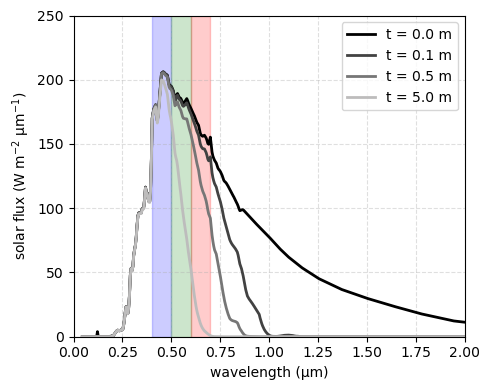

In [18]:
## calculate albedo using Schlick's approximation
n1 = 1.0 # air / vacuum
n2 = 1.33 # average refractive index of water ice
R0 = ((n1-n2)/(n1+n2))**2 # reflectance at normal incidence
R = lambda theta: R0 + (1.0 - R0)*(1 - np.cos(theta))**5 # angle-dependent reflectance
A = R(np.arccos(mu_av)) # calculate surface albedo at average incidence angle

## define Beer's Law function
Beer_Law_fun = lambda F0, t: F0*np.exp(-k_abs*t/mu_av) # calculate transmitted flux through ice thickness t

## plot results

fig,ax = plt.subplots(figsize=(5,4))

ax.plot(lambda_a*m2um, Beer_Law_fun(Fsol*(1-A)*flux_scale_factor_Mars,0.0)/m2um, linewidth = 2, color = '#000000', label = 't = 0.0 m') # plot surface solar spectrum
ax.plot(lambda_a*m2um, Beer_Law_fun(Fsol*(1-A)*flux_scale_factor_Mars,0.1)/m2um, linewidth = 2, color = '#424242', label = 't = 0.1 m') # plot spectrum through 0.1 m ice
ax.plot(lambda_a*m2um, Beer_Law_fun(Fsol*(1-A)*flux_scale_factor_Mars,0.5)/m2um, linewidth = 2, color = '#767676', label = 't = 0.5 m') # plot spectrum through 0.5 m ice
ax.plot(lambda_a*m2um, Beer_Law_fun(Fsol*(1-A)*flux_scale_factor_Mars,5.0)/m2um, linewidth = 2, color = '#bdbcbc', label = 't = 5.0 m') # plot spectrum through 5.0 m ice

ax.axvspan(0.4, 0.5, color = 'blue',  alpha = 0.2) # shade blue visible wavelengths
ax.axvspan(0.5, 0.6, color = 'green', alpha = 0.2) # shade green visible wavelengths
ax.axvspan(0.6, 0.7, color = 'red',   alpha = 0.2) # shade red visible wavelengths

ax.set_xlabel('wavelength (µm)')
ax.set_ylabel(r'solar flux (W m$^{-2}$ µm$^{-1}$)')
ax.axis([0,2.0,0,250])
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()

## Calculate the photosynthetically available radiation (PAR) for different ice thicknesses ##

In [20]:
# Convert W m-2 to umol m-2 s-1
E = sc.h*sc.c/lambda_a # J photon-1, calculate photon energy at each wavelength
F_Mars_PAR = mol2umol*Fsol*flux_scale_factor_Mars/(E*sc.N_A) # umol m-2 s-1, convert Mars spectral flux to photon flux

F_PAR = np.zeros((1,4))
PAR_mask = (lambda_a*m2um >= 0.4) & (lambda_a*m2um <= 0.7)# select PAR wavelengths (0.4–0.7 µm)
F_PAR[0,0] =  np.trapezoid(Beer_Law_fun(F_Mars_PAR,0.0)[PAR_mask],lambda_a[PAR_mask]) # calculate incident PAR on Mars surface
F_PAR[0,1] =  np.trapezoid(Beer_Law_fun(F_Mars_PAR*(1-A),0.1)[PAR_mask],lambda_a[PAR_mask]) # calculate PAR through 0.1 m ice
F_PAR[0,2] =  np.trapezoid(Beer_Law_fun(F_Mars_PAR*(1-A),0.5)[PAR_mask],lambda_a[PAR_mask]) # calculate PAR through 0.5 m ice
F_PAR[0,3] =  np.trapezoid(Beer_Law_fun(F_Mars_PAR*(1-A),5.0)[PAR_mask],lambda_a[PAR_mask]) # calculate PAR through 5.0 m ice

print('Total initial flux = ',round(np.trapezoid(Fsol*flux_scale_factor_Mars,lambda_a),2),' W m-2')
print('Total initial PAR = ',round(F_PAR[0,0],2),' umol m-2 s-1')
print('Percentage transmission = ',F_PAR/F_PAR[0,0])

252.3*145/146.62

Total initial flux =  146.62  W m-2
Total initial PAR =  252.3  umol m-2 s-1
Percentage transmission =  [[ 1.    0.93  0.85  0.5 ]]


249.51234483699358

## Calculate the CIE color for different ice thicknesses (Figure 1c) ##

$$
I = I_0 \, e^{-k_{a} t}
$$

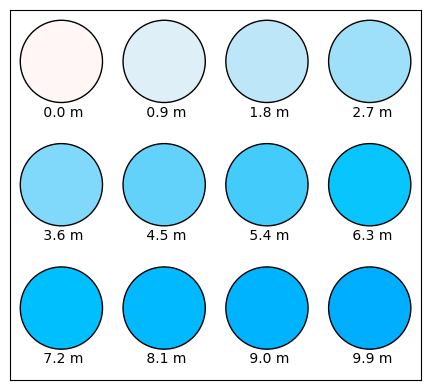

In [22]:
fig, ax = plt.subplots(figsize=(5,4))

# grid of visible wavelengths corresponding to the grid of colour-matching
# functions used by the ColourSystem instance.
lam_CIE = np.arange(380., 781., 5)

# interpolate solar flux and refractive index data onto the same uniform wavelength grid
F0_CIE = np.interp(lam_CIE, lambda_a*m2nm, Fsol*flux_scale_factor_Mars) # interpolate Mars solar spectrum onto visible grid
k_abs_CIE = np.interp(lam_CIE, lambda_a*m2nm, k_abs) # interpolate ice absorption onto visible grid

for i in range(12):
    depth = 0.9*i # set ice depth in 0.9 m increments

    spectrum = F0_CIE * np.exp(-k_abs_CIE * depth / mu_av) # calculate transmitted spectrum at depth

    html_rgb = spectrum_to_html(lam_CIE, spectrum) # convert spectrum to perceived RGB color

    # Place and label a circle with the colour of a black body at temperature T
    x, y = i % 4, -(i // 4)
    circle = Circle(xy=(x, y*1.2), radius=0.4, fc=html_rgb,edgecolor='black', linewidth=1)
    ax.add_patch(circle)
    ax.annotate('{:4.1f} m'.format(depth), xy=(x, y*1.2-0.5), va='center',
                ha='center', color='k')

# Set the limits and background colour; remove the ticks
ax.set_xlim(-0.5,3.5)
ax.set_ylim(-3.1, 0.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('w')
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Defining Ice Warming Effects Function ##

In [25]:
# Finds solution to transcendental equation for temperature
# h is convective coupling coefficient
# T1 is temperature at ice base
# F1 is solar flux at ice base
# Tsurf is surface temperature
def root_fun(Tsurf, T1, F1, h):
    return sc.sigma*Tsurf**4 - sc.sigma*T1**4 - F1 + h*(Tsurf - T1) 

In [29]:
## Ice and thermal conductivity interpolation functions

# temperature (K)
T_ice_data = np.array([0,-5,-10,-15,-20,-25,-30,-35,-40,-50,-60,-70,-80,-90,-100]) + sc.zero_Celsius

# temperature (K)
T_air_data = np.array([-190,-150,-100,-75,-50,-25,-15,-10,-5,0,5,10,15,20,25]) + sc.zero_Celsius

# ice thermal conductivity (W m^-1 K^-1)
k_cond_ice_data = np.array([2.22,2.25,2.3,2.34,2.39,2.45,2.5,
                            2.57,2.63,2.76,2.9,3.05,3.19,3.34,3.48]) # from https://www.engineeringtoolbox.com/

# air thermal conductivity (W m^-1 K^-1)
k_cond_air_data = np.array([7.82,11.69,16.2,18.34,20.41,22.41,23.2,23.59,
                            23.97,24.36,24.74,25.12,25.5,25.87,26.24])*mW2W # from https://www.engineeringtoolbox.com/


k_cond_ice_interp = interp1d(T_ice_data, k_cond_ice_data, kind='cubic', fill_value="extrapolate") # extrapolates ice thermal conductivity 
k_cond_air_interp = interp1d(T_air_data, k_cond_air_data, kind='cubic', fill_value="extrapolate") # extrapolates air thermal conductivity

In [49]:
## Ice temperature calculation function

def ice_temperature_fun(L,solar_flux_array,wavelength_array):

    Nz = 50

    z_a = np.linspace(0, L, Nz) # depth array [m]
    dz = z_a[1] - z_a[0] # depth array layer thickness [m]
    
    # get local averaged solar flux
    F_0 = np.trapezoid(solar_flux_array,lambda_a)

    # set temperature at top of layer to equilibrium temperature
    T0 = ((1-A)*F_0/sc.sigma)**(1/4)     
    
    T = T0 # initialize temperature at surface
    for i in range(1, Nz):
        F = np.trapezoid(Beer_Law_fun(solar_flux_array,z_a[i]),wavelength_array) # Use Beer's law to calculate flux at depth
        k = k_cond_ice_interp(T) # calculate ice thermal conductivity as function of depth
        dT = (F/k)*dz # calculate temperature increase across layer
        T = T + dT # update temperature at depth

    T1 = T # store temperature at bottom of ice
    F1 = F # store solar flux at bottom of ice

    return T0,T1,F1

In [51]:
## Calculate convective coupling coefficient

def calc_conv_couple_fun(g,delta_T,Tav): # define convective heat transfer function

    Ra = (g*beta*delta_T*L**3)/(nu*alpha) # calculate Rayleigh number
    k = k_cond_air_interp(Tav) # calculate air thermal conductivity at average temperature
    h = 0.14*k*Ra**0.3333/L # calculate convective heat transfer coefficient

    return h

print('hLarge = ',round(calc_conv_couple_fun(g_Mars,45,300),2),'W m^-1 K^-1') # Calculate Mars convection coefficient
print('hSmall = ',round(calc_conv_couple_fun(g_Ceres,1,150),2),'W m^-1 K^-1') # Calculate Ceres convection coefficient

# Ra is always above 2x10^7
# Range of h is from about 5 W m^-2 K^-1 (Mars with thin ice) to <0 (Ceres with thick ice)

hLarge =  4.57 W m^-1 K^-1
hSmall =  0.29 W m^-1 K^-1


## Calculate temperature and plot results (Figures 3a, 3b, 3c) ##

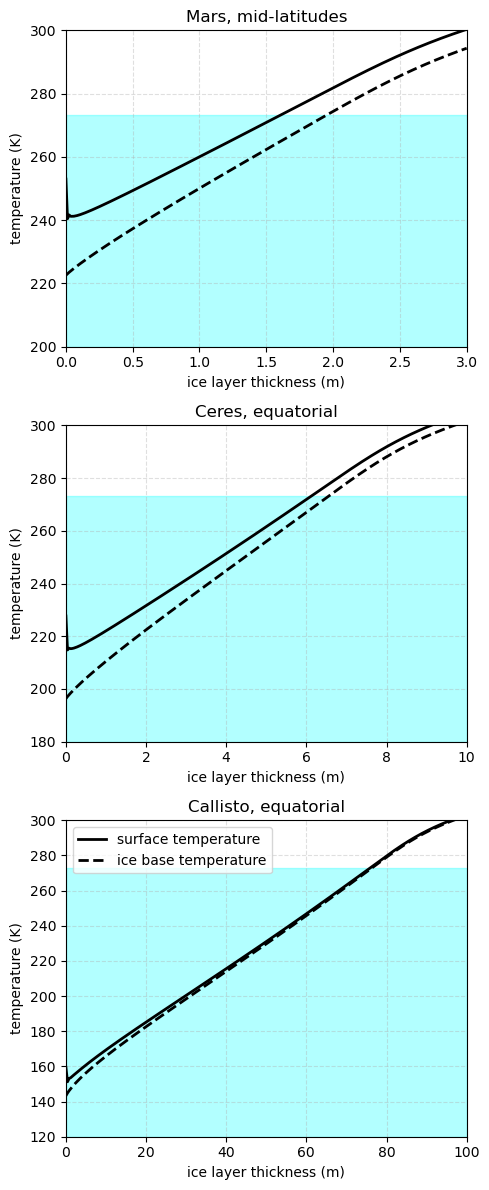

In [53]:
## Calculate temperature and plot results

plt.figure(figsize=(5, 12))

def plot_temperature_results_fun(flux_scale_factor,z1,plot_num,plot_Tmin):

    nz = 250 # number of ice thickness points
    z_a = np.linspace(0.,z1,nz) # ice thickness array
    Ts_a = z_a*0 
    T1_a = z_a*0 

    for i in range(0, nz):
        
        # get ice temperature
        T0,T1,F1 = ice_temperature_fun(z_a[i],Fsol*flux_scale_factor,lambda_a) # calculate ice temperatures and base flux
        guess = T1

        # get convection coupling coefficient 
        if i==0:
            deltaT = 40. # guess for initial choice of deltaT
            Tav = T1/2.
        else:
            deltaT = Tsurf-T1 # calculate temperature difference
            Tav = (Tsurf+T1)/2. # calculate average temperature
        h = calc_conv_couple_fun(grav_array[plot_num-1],deltaT,Tav) # calculate convection coefficient
        
        # solve full system
        sol = optimize.root(root_fun, guess, args=(T1, F1, h), method='hybr') # solve for habitat surface temperature
        Tsurf = sol.x[0] 
        Ts_a[i] = Tsurf 
        T1_a[i] = T1

    ## Plot the results

    plt.subplot(310+plot_num)
    plt.plot(z_a, Ts_a, label='surface temperature', color='k', linewidth=2) # plot surface temperature
    plt.plot(z_a, T1_a, label='ice base temperature', color='k',linestyle='--', linewidth=2) # plot ice base temperature
    plt.xlabel("ice layer thickness (m)")
    plt.ylabel("temperature (K)")
    
    if(plot_num==1):
        plt.title("Mars, mid-latitudes")
    elif(plot_num==2):
        plt.title("Ceres, equatorial")
    else:
        plt.title("Callisto, equatorial")
    
    plt.axhspan(plot_Tmin, sc.zero_Celsius, color='cyan', alpha=0.3)

    plt.xlim([0,z1])
    plt.ylim([plot_Tmin, 300])

    if plot_num == 3:
        plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()

# Mars case
plot_temperature_results_fun(flux_scale_factor_Mars,3.0,1,200) # Plot mid-latitude Mars results
# Ceres case
plot_temperature_results_fun(flux_scale_factor_Ceres,10.0,2,180) # Plot equatorial Ceres results
# Callisto case
plot_temperature_results_fun(flux_scale_factor_Callisto,100.0,3,120) # Plot equatorial Callisto results